# QAOA portfolio optimization

This notebook demonstrates binary portfolio optimization with QAOA.

We solve

$$
\min_x \; \lambda x^\top \Sigma x - \mu^\top x + \alpha \left(\sum_i x_i - k\right)^2,
$$

where:

- $x_i \in \{0,1\}$ indicates whether asset $i$ is selected,
- $\mu$ is the expected return vector,
- $\Sigma$ is the covariance matrix,
- $\lambda$ is the risk-aversion parameter,
- $k$ is the target portfolio cardinality,
- $\alpha$ is a penalty enforcing the cardinality constraint.

The notebook shows:

- a small synthetic portfolio instance,
- QAOA with the standard X mixer,
- QAOA with the XY mixer,
- how to interpret the result fields.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe_portfolio import QAOAConfig, run_qaoa

## Synthetic portfolio instance

We use a small 4-asset toy problem so the resulting binary selection is easy to inspect.

In [2]:
mu = np.array([0.16, 0.11, 0.13, 0.09], dtype=float)

Sigma = np.array(
    [
        [0.080, 0.020, 0.010, 0.000],
        [0.020, 0.070, 0.015, 0.010],
        [0.010, 0.015, 0.060, 0.020],
        [0.000, 0.010, 0.020, 0.050],
    ],
    dtype=float,
)

asset_labels = ["Asset 0", "Asset 1", "Asset 2", "Asset 3"]

k = 2
lam = 4.0
alpha = 8.0

mu, Sigma

(array([0.16, 0.11, 0.13, 0.09]),
 array([[0.08 , 0.02 , 0.01 , 0.   ],
        [0.02 , 0.07 , 0.015, 0.01 ],
        [0.01 , 0.015, 0.06 , 0.02 ],
        [0.   , 0.01 , 0.02 , 0.05 ]]))

## Helper functions

In [3]:
def objective_value(
    x: np.ndarray,
    mu: np.ndarray,
    Sigma: np.ndarray,
    lam: float,
    alpha: float,
    k: int,
) -> float:
    x = np.asarray(x, dtype=float)
    return float(lam * x @ Sigma @ x - mu @ x + alpha * (x.sum() - k) ** 2)


def bitstring_to_str(x: np.ndarray) -> str:
    return "".join(str(int(v)) for v in np.asarray(x))


def summarize_result(
    name: str, res, mu, Sigma, lam: float, alpha: float, k: int
) -> None:
    print(f"{name}")
    print("-" * len(name))
    print("gammas:", np.asarray(res.gammas))
    print("betas :", np.asarray(res.betas))
    print("x_prob:", np.asarray(res.x_prob))
    print("x_round:", np.asarray(res.x_round))
    print("x_topk :", np.asarray(res.x_topk))
    print("x_mode :", np.asarray(res.x_mode))

    if res.x_best_feasible is None:
        print("x_best_feasible: None")
    else:
        x_best = np.asarray(res.x_best_feasible, dtype=int)
        val = objective_value(x_best, mu, Sigma, lam=lam, alpha=alpha, k=k)
        print(
            "x_best_feasible:",
            x_best,
            f"(bitstring={bitstring_to_str(x_best)}, objective={val:.6f})",
        )

    print("sample_counts (top 10):")
    items = sorted(res.sample_counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
    for bitstring, count in items:
        print(f"  {bitstring}: {count}")
    print()


def plot_selection_probs(title: str, x_prob: np.ndarray, labels: list[str]) -> None:
    x_prob = np.asarray(x_prob, dtype=float)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, x_prob)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Selection probability")
    ax.set_title(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_cost_trace(title: str, steps, values) -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(steps, values, marker="o")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cost")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## QAOA with the standard X mixer

This is the standard unconstrained mixer. The cardinality condition is encouraged by the penalty term and then enforced downstream using `x_topk` or `x_best_feasible`.

In [4]:
cfg_x = QAOAConfig(
    p=2,
    steps=60,
    stepsize=0.15,
    log_every=10,
    lam=lam,
    alpha=alpha,
    k=k,
    mixer="x",
    device="default.qubit",
    shots_train=None,
    shots_sample=2000,
    seed=0,
)

res_x = run_qaoa(mu=mu, Sigma=Sigma, cfg=cfg_x)

In [5]:
summarize_result("QAOA with X mixer", res_x, mu, Sigma, lam=lam, alpha=alpha, k=k)

QAOA with X mixer
-----------------
gammas: [2.00553999 2.59438412]
betas : [1.70186445 1.75728918]
x_prob: [0.47506437 0.46101821 0.47544195 0.48793738]
x_round: [0 0 0 0]
x_topk : [0 0 1 1]
x_mode : [0 0 1 1]
x_best_feasible: [1 0 0 1] (bitstring=1001, objective=0.270000)
sample_counts (top 10):
  0011: 290
  1100: 255
  1001: 254
  0101: 250
  1010: 244
  0110: 231
  0001: 98
  1000: 93
  0010: 69
  0100: 56



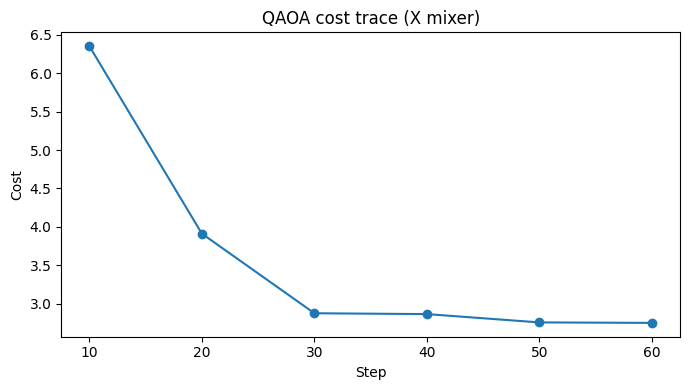

In [6]:
plot_cost_trace(
    "QAOA cost trace (X mixer)",
    res_x.cost_trace.steps,
    res_x.cost_trace.values,
)

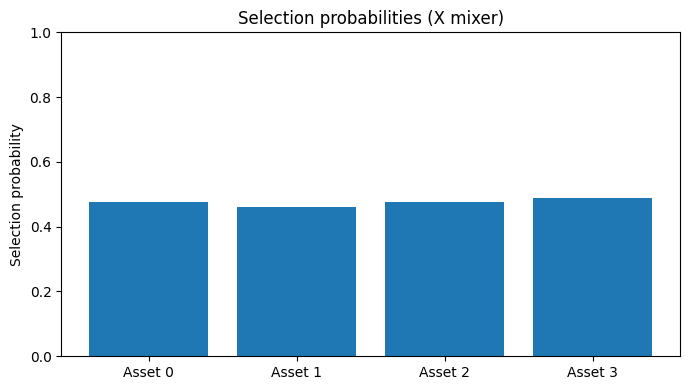

In [7]:
plot_selection_probs(
    "Selection probabilities (X mixer)",
    res_x.x_prob,
    asset_labels,
)

## Interpreting the result fields

The main binary outputs are:

- `x_prob`: marginal selection probabilities for each asset,
- `x_round`: thresholded version of `x_prob`,
- `x_topk`: top-$k$ projection of `x_prob`,
- `x_mode`: most frequently sampled bitstring,
- `x_best_feasible`: best sampled feasible bitstring with exactly `k` selected assets.

In [8]:
x_prob_x = np.asarray(res_x.x_prob, dtype=float)
x_round_x = np.asarray(res_x.x_round, dtype=int)
x_topk_x = np.asarray(res_x.x_topk, dtype=int)
x_mode_x = np.asarray(res_x.x_mode, dtype=int)
x_best_x = (
    None
    if res_x.x_best_feasible is None
    else np.asarray(res_x.x_best_feasible, dtype=int)
)

print("x_prob         :", x_prob_x)
print("x_round        :", x_round_x, "sum =", int(x_round_x.sum()))
print("x_topk         :", x_topk_x, "sum =", int(x_topk_x.sum()))
print("x_mode         :", x_mode_x, "sum =", int(x_mode_x.sum()))
print(
    "x_best_feasible:",
    x_best_x,
    "sum =",
    None if x_best_x is None else int(x_best_x.sum()),
)

x_prob         : [0.47506437 0.46101821 0.47544195 0.48793738]
x_round        : [0 0 0 0] sum = 0
x_topk         : [0 0 1 1] sum = 2
x_mode         : [0 0 1 1] sum = 2
x_best_feasible: [1 0 0 1] sum = 2


In [9]:
candidates_x = {
    "x_round": x_round_x,
    "x_topk": x_topk_x,
    "x_mode": x_mode_x,
}

if x_best_x is not None:
    candidates_x["x_best_feasible"] = x_best_x

for name, x in candidates_x.items():
    value = objective_value(x, mu, Sigma, lam=lam, alpha=alpha, k=k)
    print(f"{name:16s} bitstring={bitstring_to_str(x)} objective={value:.6f}")

x_round          bitstring=0000 objective=32.000000
x_topk           bitstring=0011 objective=0.380000
x_mode           bitstring=0011 objective=0.380000
x_best_feasible  bitstring=1001 objective=0.270000


## QAOA with the XY mixer

The XY mixer is often used in constrained binary optimization because it better respects fixed-Hamming-weight structure.

In [10]:
cfg_xy = QAOAConfig(
    p=2,
    steps=60,
    stepsize=0.15,
    log_every=10,
    lam=lam,
    alpha=alpha,
    k=k,
    mixer="xy",
    device="default.qubit",
    shots_train=None,
    shots_sample=2000,
    seed=0,
)

res_xy = run_qaoa(mu=mu, Sigma=Sigma, cfg=cfg_xy)

In [11]:
summarize_result("QAOA with XY mixer", res_xy, mu, Sigma, lam=lam, alpha=alpha, k=k)

QAOA with XY mixer
------------------
gammas: [1.86247597 1.95437019]
betas : [2.48376479 3.23169783]
x_prob: [0.17202533 0.17207434 0.82792566 0.82797467]
x_round: [0 0 1 1]
x_topk : [0 0 1 1]
x_mode : [0 0 1 1]
x_best_feasible: [1 0 0 1] (bitstring=1001, objective=0.270000)
sample_counts (top 10):
  0011: 1389
  0101: 264
  1010: 256
  1100: 57
  1001: 18
  0110: 16



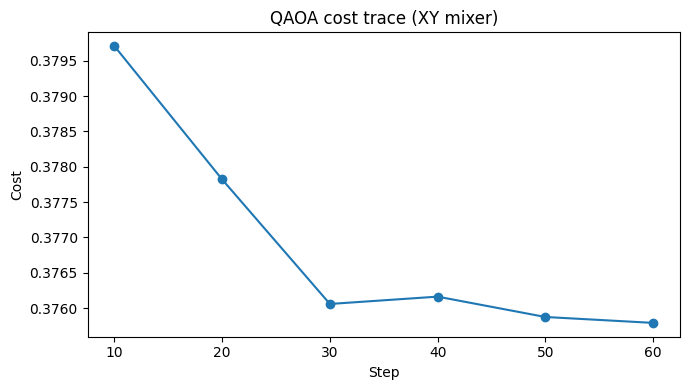

In [12]:
plot_cost_trace(
    "QAOA cost trace (XY mixer)",
    res_xy.cost_trace.steps,
    res_xy.cost_trace.values,
)

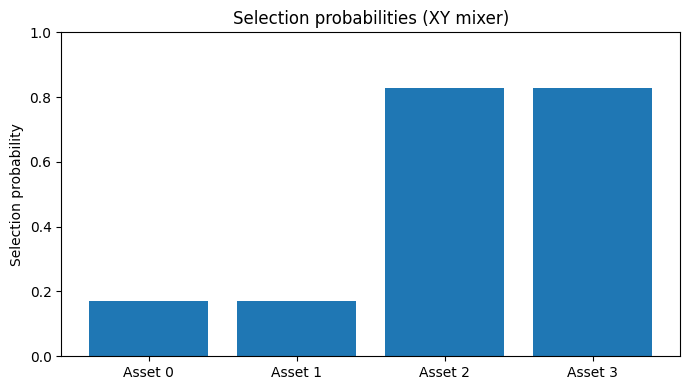

In [13]:
plot_selection_probs(
    "Selection probabilities (XY mixer)",
    res_xy.x_prob,
    asset_labels,
)

## Compare the two mixers

In [14]:
rows = []

for name, res in [("x", res_x), ("xy", res_xy)]:
    x_topk = np.asarray(res.x_topk, dtype=int)
    x_mode = np.asarray(res.x_mode, dtype=int)
    x_best = (
        None
        if res.x_best_feasible is None
        else np.asarray(res.x_best_feasible, dtype=int)
    )

    rows.append(
        {
            "mixer": name,
            "x_topk": bitstring_to_str(x_topk),
            "x_topk_objective": objective_value(
                x_topk, mu, Sigma, lam=lam, alpha=alpha, k=k
            ),
            "x_mode": bitstring_to_str(x_mode),
            "x_mode_objective": objective_value(
                x_mode, mu, Sigma, lam=lam, alpha=alpha, k=k
            ),
            "x_best_feasible": None if x_best is None else bitstring_to_str(x_best),
            "x_best_feasible_objective": (
                None
                if x_best is None
                else objective_value(x_best, mu, Sigma, lam=lam, alpha=alpha, k=k)
            ),
        }
    )

rows

[{'mixer': 'x',
  'x_topk': '0011',
  'x_topk_objective': 0.3800000000000001,
  'x_mode': '0011',
  'x_mode_objective': 0.3800000000000001,
  'x_best_feasible': '1001',
  'x_best_feasible_objective': 0.27},
 {'mixer': 'xy',
  'x_topk': '0011',
  'x_topk_objective': 0.3800000000000001,
  'x_mode': '0011',
  'x_mode_objective': 0.3800000000000001,
  'x_best_feasible': '1001',
  'x_best_feasible_objective': 0.27}]

## Inspect the best feasible sampled portfolio

In [15]:
x_final = np.asarray(
    res_xy.x_best_feasible if res_xy.x_best_feasible is not None else res_xy.x_topk,
    dtype=int,
)

selected_assets = [label for label, bit in zip(asset_labels, x_final) if bit == 1]
portfolio_return = float(mu @ x_final)
portfolio_risk = float(x_final @ Sigma @ x_final)
portfolio_objective = objective_value(x_final, mu, Sigma, lam=lam, alpha=alpha, k=k)

print("Chosen bitstring :", bitstring_to_str(x_final))
print("Selected assets  :", selected_assets)
print("Expected return  :", portfolio_return)
print("Quadratic risk   :", portfolio_risk)
print("Objective        :", portfolio_objective)

Chosen bitstring : 1001
Selected assets  : ['Asset 0', 'Asset 3']
Expected return  : 0.25
Quadratic risk   : 0.13
Objective        : 0.27


## Notes

In practice:

- use `x_topk` when you want a deterministic exactly-$k$ portfolio from the marginals,
- use `x_best_feasible` when you want the best feasible sampled candidate,
- compare X and XY mixers on the same problem instance,
- increase `p`, `steps`, or `shots_sample` for stronger optimization runs.